In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Handling

## Dataset Construction

In [4]:
from src.datasets.multi_season_dataset import build_multi_season_dataset


raw_X, raw_y, final_team_states_df = build_multi_season_dataset(
    seasons=list(range(2003, 2027))
)

print(f"\nX shape: {raw_X.shape}")
print(f"Number of features: {len(raw_X.columns)}")
print("Train features:")
print(list(raw_X.columns))

Starting season 2003...
Finished season 2003: 4413 rows built, 203 skipped, 4616 raw games
Starting season 2004...
Finished season 2004: 4364 rows built, 207 skipped, 4571 raw games
Starting season 2005...
Finished season 2005: 4465 rows built, 210 skipped, 4675 raw games
Starting season 2006...
Finished season 2006: 4541 rows built, 216 skipped, 4757 raw games
Starting season 2007...
Finished season 2007: 4835 rows built, 208 skipped, 5043 raw games
Starting season 2008...
Finished season 2008: 4954 rows built, 209 skipped, 5163 raw games
Starting season 2009...
Finished season 2009: 5038 rows built, 211 skipped, 5249 raw games
Starting season 2010...
Finished season 2010: 5051 rows built, 212 skipped, 5263 raw games
Starting season 2011...
Finished season 2011: 5033 rows built, 213 skipped, 5246 raw games
Starting season 2012...
Finished season 2012: 5039 rows built, 214 skipped, 5253 raw games
Starting season 2013...
Finished season 2013: 5112 rows built, 208 skipped, 5320 raw games

In [5]:
from pathlib import Path

data_dir = Path("../../data")

final_team_states_df.to_csv(
    data_dir / "final_team_states.csv",
    index=False,
)

print("Saved to:", data_dir / "final_team_states.csv")

Saved to: ..\..\data\final_team_states.csv


## Split

In [6]:
from src.preprocessing.splits import split_raw_by_season

# Hold out the 2026 season as the test set
raw_X_train, raw_X_test, raw_y_train, raw_y_test = split_raw_by_season(
    raw_X,
    raw_y,
    test_seasons=[2026],
)

print("Train shape:", raw_X_train.shape)
print("Test shape:", raw_X_test.shape)

Train shape: (113986, 131)
Test shape: (5426, 131)


## Feature Engineering

In [7]:
from src.feature_engineering.feature_analysis import FeatureAnalyzer

# Training data determines feature-engineering decisions.
# Test data only receives the same fixed transformations.
train_analyzer = FeatureAnalyzer(raw_X_train)
test_analyzer = FeatureAnalyzer(raw_X_test)


# ---------------------------------------------------------
# 1. Correlation analysis — TRAIN ONLY
# ---------------------------------------------------------

corr = train_analyzer.analyze_collinearity(threshold=0.90)

redundant_features = [
    "team_1_last_10_avg_opponent_win_pct",
    "team_2_last_10_avg_opponent_win_pct",
    "team_1_last_5_avg_opponent_win_pct",
    "team_2_last_5_avg_opponent_win_pct",
    "team_1_wins",
    "team_2_wins",
    "team_1_losses",
    "team_2_losses",
]

for analyzer in [train_analyzer, test_analyzer]:
    analyzer.remove(redundant_features)


# ---------------------------------------------------------
# 2. Create chosen interaction features
#    identically in train and test
# ---------------------------------------------------------

for analyzer in [train_analyzer, test_analyzer]:

    analyzer.interaction(
        "team_1_games_played",
        "team_1_win_pct",
        "team_1_wins_ratio",
        "exponent"
    )

    analyzer.interaction(
        "team_2_games_played",
        "team_2_win_pct",
        "team_2_wins_ratio",
        "exponent"
    )

    analyzer.interaction(
        "team_1_home_win_pct",
        "team_1_location",
        "team_1_home_strength",
        "location"
    )

    analyzer.interaction(
        "team_1_neutral_win_pct",
        "team_1_location",
        "team_1_neutral_strength",
        "location"
    )

    analyzer.interaction(
        "team_1_away_win_pct",
        "team_1_location",
        "team_1_away_strength",
        "location"
    )

    analyzer.interaction(
        "team_2_home_win_pct",
        "team_1_location",
        "team_2_home_strength",
        "location"
    )

    analyzer.interaction(
        "team_2_neutral_win_pct",
        "team_1_location",
        "team_2_neutral_strength",
        "location"
    )

    analyzer.interaction(
        "team_2_away_win_pct",
        "team_1_location",
        "team_2_away_strength",
        "location"
    )


# ---------------------------------------------------------
# 3. Remove base features replaced by interactions
# ---------------------------------------------------------

replaced_features = [
    "team_1_games_played",
    "team_1_win_pct",
    "team_2_games_played",
    "team_2_win_pct",

    "team_1_home_win_pct",
    "team_1_neutral_win_pct",
    "team_1_away_win_pct",

    "team_2_home_win_pct",
    "team_2_neutral_win_pct",
    "team_2_away_win_pct",

    "team_1_location",
]

for analyzer in [train_analyzer, test_analyzer]:
    analyzer.remove(replaced_features)


# ---------------------------------------------------------
# 4. Retrieve engineered datasets
# ---------------------------------------------------------

raw_X_train = train_analyzer.get_data()
raw_X_test = test_analyzer.get_data()

assert raw_X_train.columns.tolist() == raw_X_test.columns.tolist()

print("Engineered train shape:", raw_X_train.shape)
print("Engineered test shape:", raw_X_test.shape)

Highly Correlated Feature Pairs
0.992 team_1_last_10_avg_opponent_win_pct <-> team_1_avg_opponent_win_pct
0.992 team_2_last_10_avg_opponent_win_pct <-> team_2_avg_opponent_win_pct
0.991 team_1_last_10_avg_opponent_point_diff_pg <-> team_1_avg_opponent_point_diff_pg
0.990 team_2_last_10_avg_opponent_point_diff_pg <-> team_2_avg_opponent_point_diff_pg
0.979 team_1_games_played <-> team_2_games_played
0.968 team_2_last_5_avg_opponent_win_pct <-> team_2_last_10_avg_opponent_win_pct
0.968 team_1_last_5_avg_opponent_win_pct <-> team_1_last_10_avg_opponent_win_pct
0.966 DayNum <-> team_2_games_played
0.965 DayNum <-> team_1_games_played
0.964 team_1_last_5_avg_opponent_point_diff_pg <-> team_1_last_10_avg_opponent_point_diff_pg
0.964 team_2_last_5_avg_opponent_point_diff_pg <-> team_2_last_10_avg_opponent_point_diff_pg
0.962 team_2_off_rebounds_pg <-> team_2_last_10_off_rebounds_pg
0.960 team_1_off_rebounds_pg <-> team_1_last_10_off_rebounds_pg
0.960 team_2_last_5_avg_opponent_win_pct <-> tea

## Preprocessing

In [8]:
from src.preprocessing.preprocess import preprocess_train_test

X_train, X_test, y_train, y_test = preprocess_train_test(
    raw_X_train,
    raw_X_test,
    raw_y_train,
    raw_y_test,
    prefix1="team_1_",
    prefix2="team_2_",
    invert_cols=["team_1_location"],
    diff_suffix="_diff",
    drop_base_features=True,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of model features:", X_train.shape[1])
print("Train/Test columns identical:",
      X_train.columns.tolist() == X_test.columns.tolist())

Processing Training Set:
--- Symmetrizing Dataset ---
Identified 59 base features to swap between team_1_ and team_2_:
['id', 'name', 'ppg', 'papg', 'fg_pct', 'fg3_pct', 'ft_pct', 'off_rebounds_pg', 'def_rebounds_pg', 'assists_pg', 'turnovers_pg', 'steals_pg', 'blocks_pg', 'personal_fouls_pg', 'last_5_games_played', 'last_5_win_pct', 'last_5_ppg', 'last_5_papg', 'last_5_fg_pct', 'last_5_fg3_pct', 'last_5_ft_pct', 'last_5_off_rebounds_pg', 'last_5_def_rebounds_pg', 'last_5_assists_pg', 'last_5_turnovers_pg', 'last_5_steals_pg', 'last_5_blocks_pg', 'last_5_personal_fouls_pg', 'last_5_avg_opponent_point_diff_pg', 'last_10_games_played', 'last_10_win_pct', 'last_10_ppg', 'last_10_papg', 'last_10_fg_pct', 'last_10_fg3_pct', 'last_10_ft_pct', 'last_10_off_rebounds_pg', 'last_10_def_rebounds_pg', 'last_10_assists_pg', 'last_10_turnovers_pg', 'last_10_steals_pg', 'last_10_blocks_pg', 'last_10_personal_fouls_pg', 'last_10_avg_opponent_point_diff_pg', 'current_win_streak', 'current_loss_streak',

## Feature Selection

Subsampling 40000 rows from 227972 for Lasso speed...
--- Lasso (L1 Regularization Path) ---
Selected (35): ['last_5_blocks_pg_diff', 'last_10_def_rebounds_pg_diff', 'def_rebounds_pg_diff', 'last_10_blocks_pg_diff', 'avg_opponent_win_pct_diff', 'away_strength_diff', 'last_10_games_played_diff', 'last_10_steals_pg_diff', 'last_10_off_rebounds_pg_diff', 'last_5_games_played_diff', 'current_win_streak_diff', 'last_5_steals_pg_diff', 'turnovers_pg_diff', 'last_5_win_pct_diff', 'steals_pg_diff', 'point_diff_pg_diff', 'last_5_turnovers_pg_diff', 'last_5_off_rebounds_pg_diff', 'papg_diff', 'assists_pg_diff', 'off_rebounds_pg_diff', 'last_5_ppg_diff', 'last_10_fg_pct_diff', 'last_5_fg_pct_diff', 'fg3_attempt_rate_diff', 'ppg_diff', 'last_10_win_pct_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'wins_ratio_diff', 'effective_fg_pct_diff', 'home_strength_diff', 'fg_pct_diff', 'avg_opponent_point_diff_pg_diff']
Removed  (22): ['fg3_pct_diff', 'ft_pct_di

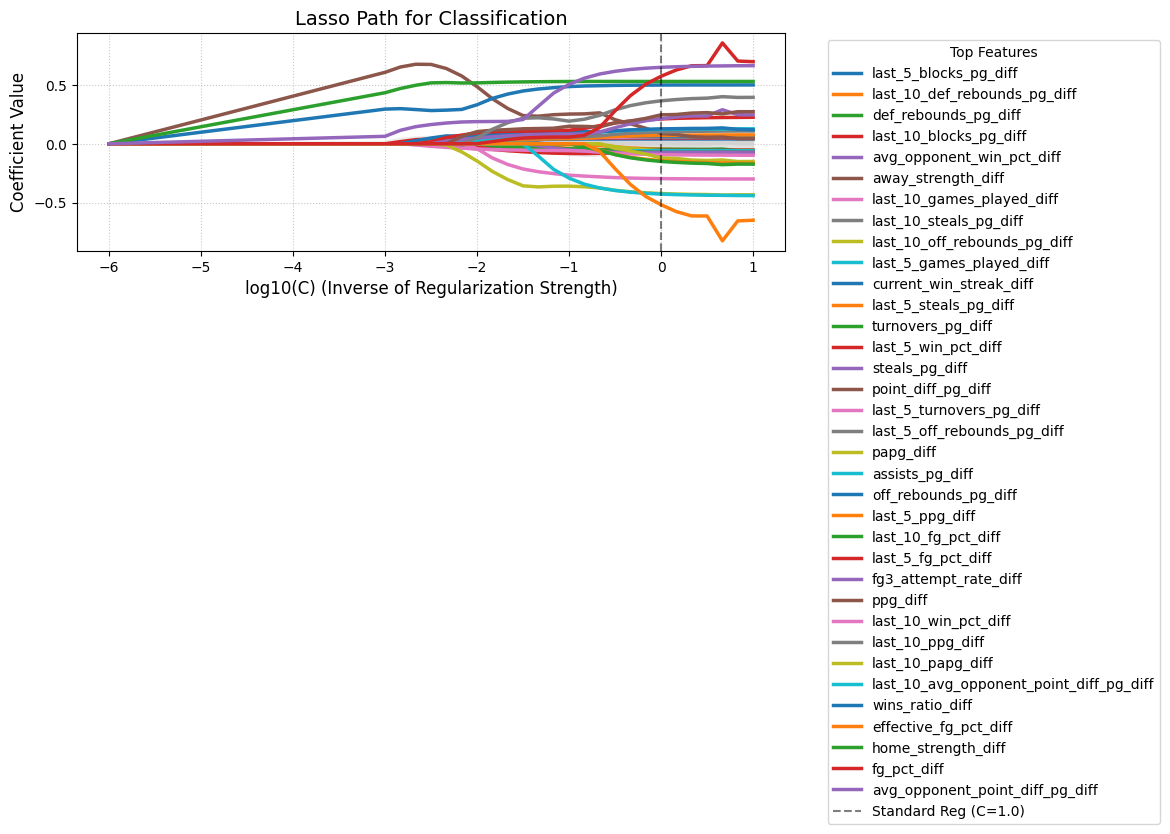

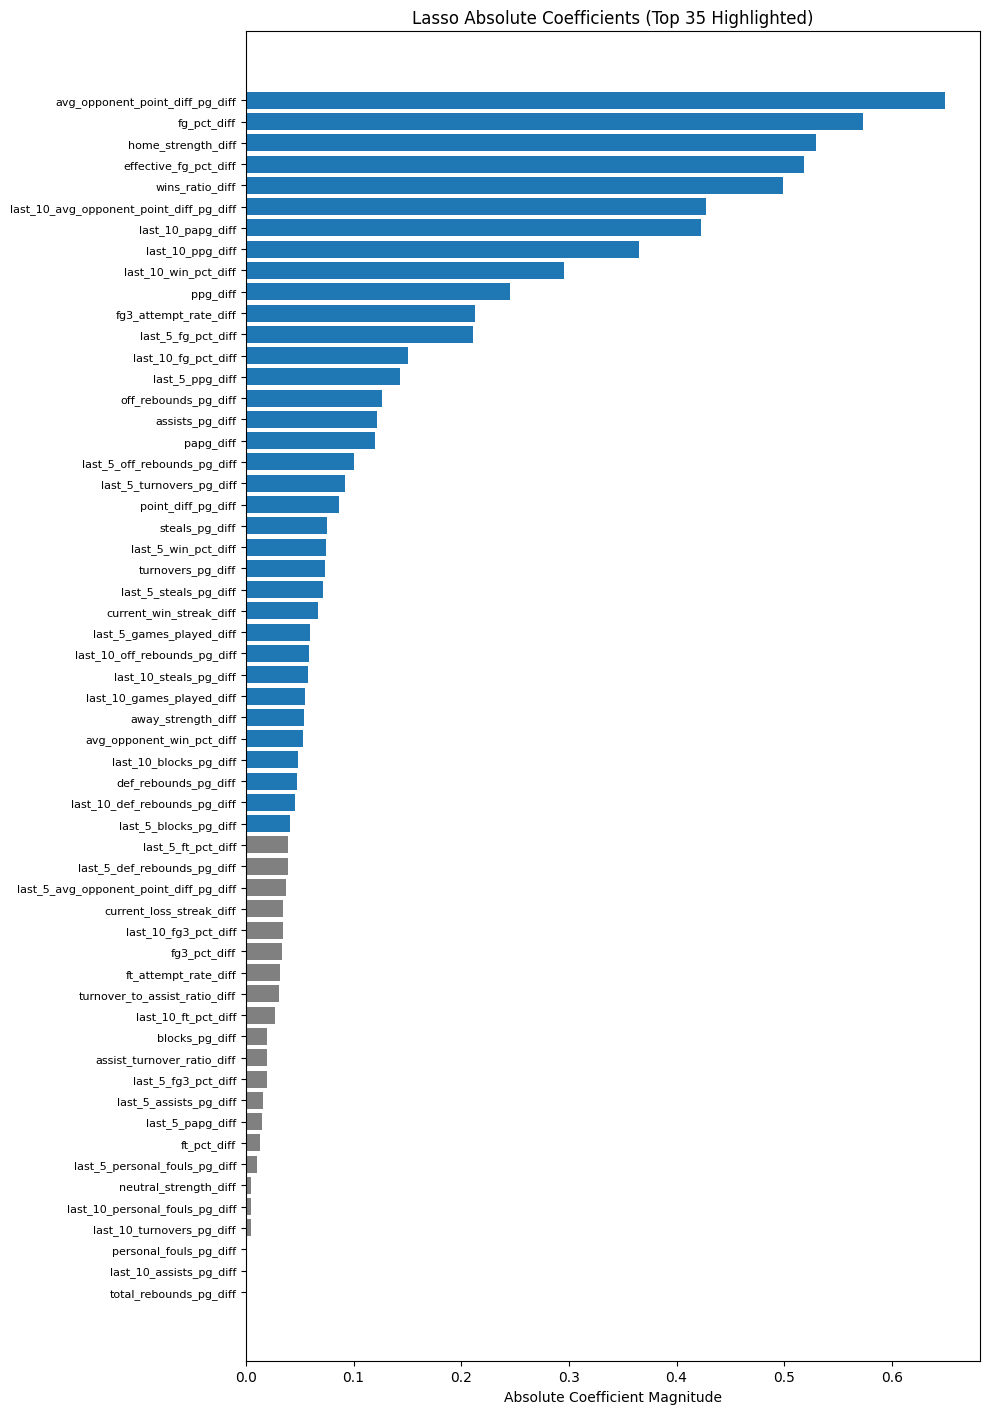

--- Recursive Feature Elimination (Backward) ---
Selected (35): ['ppg_diff', 'papg_diff', 'fg_pct_diff', 'ft_pct_diff', 'off_rebounds_pg_diff', 'assists_pg_diff', 'turnovers_pg_diff', 'personal_fouls_pg_diff', 'last_5_win_pct_diff', 'last_5_papg_diff', 'last_5_fg_pct_diff', 'last_5_ft_pct_diff', 'last_5_off_rebounds_pg_diff', 'last_5_steals_pg_diff', 'last_5_avg_opponent_point_diff_pg_diff', 'last_10_games_played_diff', 'last_10_win_pct_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'last_10_def_rebounds_pg_diff', 'last_10_blocks_pg_diff', 'last_10_personal_fouls_pg_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'current_win_streak_diff', 'current_loss_streak_diff', 'point_diff_pg_diff', 'effective_fg_pct_diff', 'fg3_attempt_rate_diff', 'ft_attempt_rate_diff', 'turnover_to_assist_ratio_diff', 'avg_opponent_win_pct_diff', 'avg_opponent_point_diff_pg_diff', 'wins_ratio_diff', 'home_strength_diff', 'away_strength_diff']
Removed  (22): ['fg3_pct_diff', 'def_rebounds_pg_diff', 'steals_p

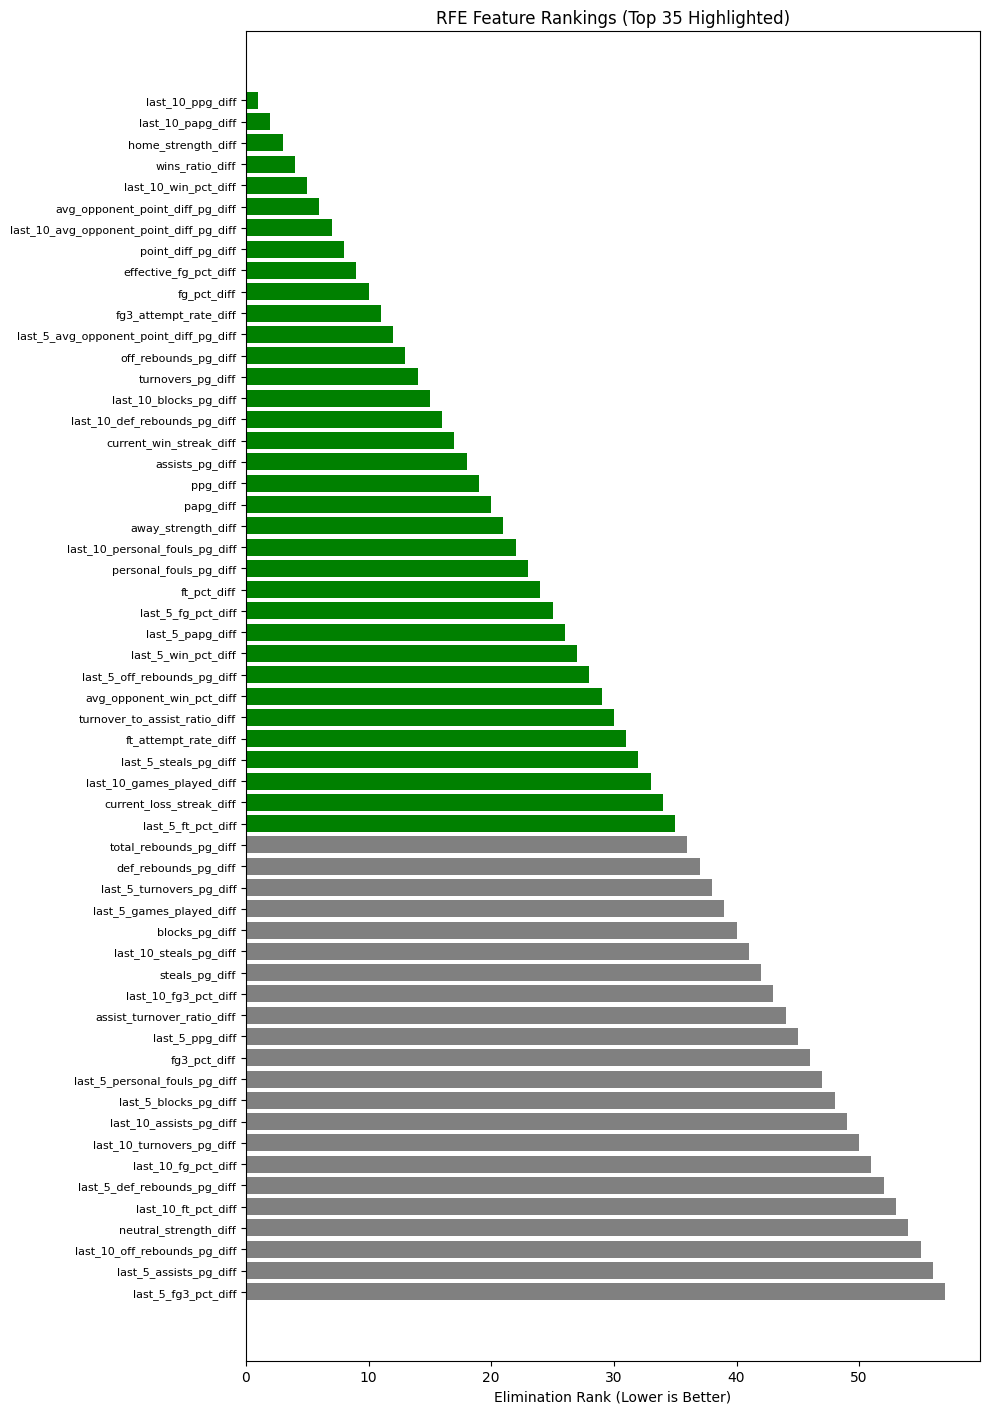

--- Random Forest Importance ---
Selected (35): ['last_10_ft_pct_diff', 'steals_pg_diff', 'turnovers_pg_diff', 'last_10_fg3_pct_diff', 'ft_pct_diff', 'total_rebounds_pg_diff', 'last_5_ft_pct_diff', 'fg3_pct_diff', 'blocks_pg_diff', 'last_5_fg3_pct_diff', 'last_5_fg_pct_diff', 'off_rebounds_pg_diff', 'fg3_attempt_rate_diff', 'last_5_ppg_diff', 'ft_attempt_rate_diff', 'last_5_avg_opponent_point_diff_pg_diff', 'assists_pg_diff', 'effective_fg_pct_diff', 'last_5_papg_diff', 'last_10_fg_pct_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'avg_opponent_win_pct_diff', 'avg_opponent_point_diff_pg_diff', 'assist_turnover_ratio_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'papg_diff', 'away_strength_diff', 'ppg_diff', 'turnover_to_assist_ratio_diff', 'last_10_win_pct_diff', 'fg_pct_diff', 'wins_ratio_diff', 'home_strength_diff', 'point_diff_pg_diff']
Removed  (22): ['def_rebounds_pg_diff', 'personal_fouls_pg_diff', 'last_5_games_played_diff', 'last_5_win_pct_diff', 'last_5_off_rebounds_pg_d

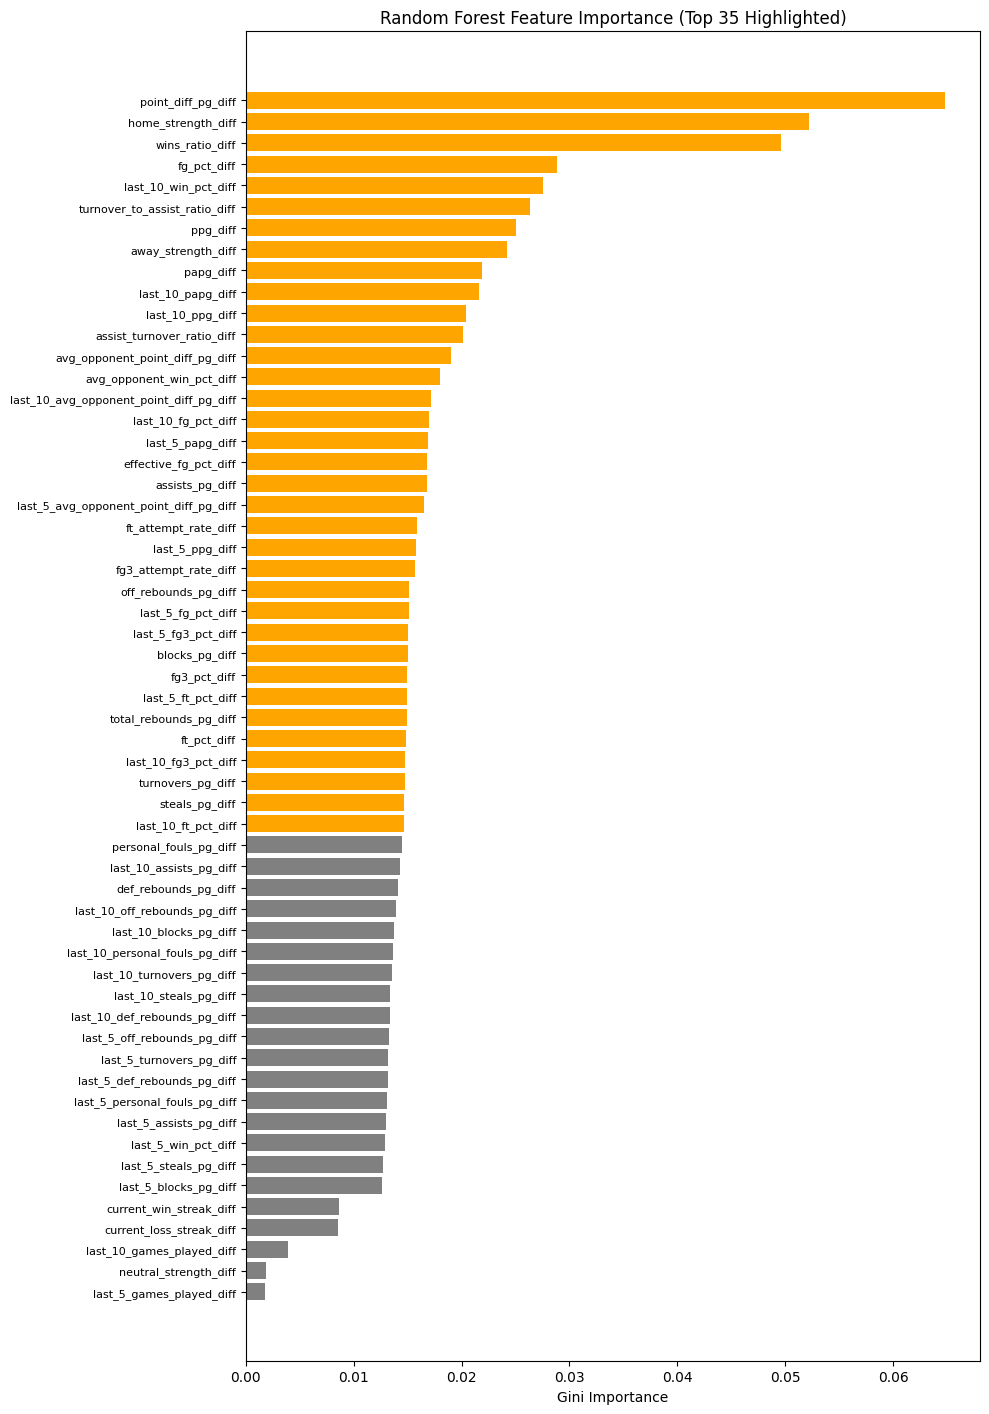

FINAL FEATURE SELECTION VERDICT
Target Threshold: 2 votes required
Total Features Selected: 35

Detailed Voting Breakdown:
[KEEP] assists_pg_diff: 3 vote(s)
[KEEP] avg_opponent_point_diff_pg_diff: 3 vote(s)
[KEEP] avg_opponent_win_pct_diff: 3 vote(s)
[KEEP] away_strength_diff: 3 vote(s)
[KEEP] effective_fg_pct_diff: 3 vote(s)
[KEEP] fg3_attempt_rate_diff: 3 vote(s)
[KEEP] fg_pct_diff: 3 vote(s)
[KEEP] home_strength_diff: 3 vote(s)
[KEEP] last_10_avg_opponent_point_diff_pg_diff: 3 vote(s)
[KEEP] last_10_papg_diff: 3 vote(s)
[KEEP] last_10_ppg_diff: 3 vote(s)
[KEEP] last_10_win_pct_diff: 3 vote(s)
[KEEP] last_5_fg_pct_diff: 3 vote(s)
[KEEP] off_rebounds_pg_diff: 3 vote(s)
[KEEP] papg_diff: 3 vote(s)
[KEEP] point_diff_pg_diff: 3 vote(s)
[KEEP] ppg_diff: 3 vote(s)
[KEEP] turnovers_pg_diff: 3 vote(s)
[KEEP] wins_ratio_diff: 3 vote(s)
[KEEP] current_win_streak_diff: 2 vote(s)
[KEEP] ft_attempt_rate_diff: 2 vote(s)
[KEEP] ft_pct_diff: 2 vote(s)
[KEEP] last_10_blocks_pg_diff: 2 vote(s)
[KEEP] 

In [9]:
from src.feature_engineering.feature_selector import FeatureSelector
import warnings

# ---------------------------------------------------------
# Final feature selection — TRAIN ONLY
# ---------------------------------------------------------

selector = FeatureSelector(X_train, y_train)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model"
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn.linear_model"
)

# 1. Lasso
selector.run_lasso(
    target_features=35,
    print_results=True,
    plot_results=True
)

# 2. Recursive Feature Elimination
selector.run_rfe(
    target_features=35,
    print_results=True,
    plot_results=True
)

# 3. Tree-based feature importance
selector.run_tree_importance(
    target_features=35,
    print_results=True,
    plot_results=True
)

# 4. Keep features supported by at least two methods
selector.finalize_selection(
    vote_threshold=2,
    print_results=True
)

# 5. Apply the SAME selected feature set to train and test
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

# Sanity checks
assert X_train.columns.tolist() == X_test.columns.tolist()

print("\nFinal X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)
print("Final number of features:", X_train.shape[1])

In [10]:
from pathlib import Path
import json

artifacts_dir = Path("../../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

feature_columns = X_train.columns.tolist()

with open(artifacts_dir / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print(f"Saved {len(feature_columns)} selected features.")

Saved 35 selected features.


## Save final datasets

In [11]:
from pathlib import Path
import pandas as pd

data_dir = Path("../../data")

# Save final train/test feature matrices
X_train.to_csv(data_dir / "X_train.csv", index=False)
X_test.to_csv(data_dir / "X_test.csv", index=False)

# Save labels
y_train.to_csv(data_dir / "y_train.csv", index=False)
y_test.to_csv(data_dir / "y_test.csv", index=False)

# Save final selected feature names
pd.Series(X_train.columns, name="feature").to_csv(
    data_dir / "selected_features.csv",
    index=False
)

print("Saved:")
print(data_dir / "X_train.csv")
print(data_dir / "X_test.csv")
print(data_dir / "y_train.csv")
print(data_dir / "y_test.csv")
print(data_dir / "selected_features.csv")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Saved:
..\..\data\X_train.csv
..\..\data\X_test.csv
..\..\data\y_train.csv
..\..\data\y_test.csv
..\..\data\selected_features.csv

Shapes:
X_train: (227972, 35)
X_test: (5426, 35)
y_train: (227972,)
y_test: (5426,)


# Model Building

In [12]:
from src.predictors.predictors import EnsembleLearner
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


def print_evaluation(sub_model, X_train, X_test, y_train, y_test):
    sub_model_eval = clone(sub_model)
    sub_model_eval.fit(X_train, y_train)
    results = evaluate_classifier(
        sub_model_eval,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    print_classifier_results(results)

model = EnsembleLearner(meta_test_size=0.15)
print("Initializing model...")

Initializing model...


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

logistic_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=0.1,
        solver="lbfgs",
        max_iter=10000
    ))
])

print_evaluation(
    logistic_regression,
    X_train,
    X_test,
    y_train,
    y_test
)

model.add_learner(
    "Logistic Regression (L2)",
    logistic_regression
)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 71.67%
Test accuracy   : 70.14%

Train log loss  : 0.5430
Test log loss   : 0.5545

Train ROC-AUC   : 0.7966
Test ROC-AUC    : 0.7831

Train confusion matrix:
[[81692 32294]
 [32294 81692]]

Test confusion matrix:
[[1991  828]
 [ 792 1815]]


In [14]:
from lightgbm import LGBMClassifier

# Add LightGBM (The dominant algorithm for Men's data)
lightgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
)
print_evaluation(lightgbm, X_train, X_test, y_train, y_test)
model.add_learner("LightGBM", lightgbm)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 72.56%
Test accuracy   : 70.70%

Train log loss  : 0.5298
Test log loss   : 0.5519

Train ROC-AUC   : 0.8081
Test ROC-AUC    : 0.7863

Train confusion matrix:
[[82701 31285]
 [31276 82710]]

Test confusion matrix:
[[2015  804]
 [ 786 1821]]


In [15]:
from xgboost import XGBClassifier

# Add XGBoost (Constrain depth to prevent memorization)
xgboost = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
)
print_evaluation(xgboost, X_train, X_test, y_train, y_test)
model.add_learner("XGBoost", xgboost)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 72.91%
Test accuracy   : 70.75%

Train log loss  : 0.5245
Test log loss   : 0.5501

Train ROC-AUC   : 0.8126
Test ROC-AUC    : 0.7876

Train confusion matrix:
[[83190 30796]
 [30954 83032]]

Test confusion matrix:
[[2023  796]
 [ 791 1816]]


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Add Random Forest
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
print_evaluation(random_forest, X_train, X_test, y_train, y_test)
model.add_learner("Random Forest", random_forest)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 75.75%
Test accuracy   : 70.86%

Train log loss  : 0.4949
Test log loss   : 0.5518

Train ROC-AUC   : 0.8454
Test ROC-AUC    : 0.7852

Train confusion matrix:
[[86399 27587]
 [27698 86288]]

Test confusion matrix:
[[2018  801]
 [ 780 1827]]


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add KNN classifier
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="distance",
        metric="minkowski",
        p=2,
    ))
])
print_evaluation(knn, X_train, X_test, y_train, y_test)
model.add_learner("KNN Classifier", knn)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 100.00%
Test accuracy   : 69.54%

Train log loss  : 0.0000
Test log loss   : 0.5704

Train ROC-AUC   : 1.0000
Test ROC-AUC    : 0.7741

Train confusion matrix:
[[113986      0]
 [     0 113986]]

Test confusion matrix:
[[2005  814]
 [ 839 1768]]


In [18]:
from sklearn.neural_network import MLPClassifier

# Add Basic Neural Network
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42,
    ))
])
print_evaluation(mlp, X_train, X_test, y_train, y_test)
model.add_learner("Basic Neural Network", mlp)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 72.50%
Test accuracy   : 70.27%

Train log loss  : 0.5319
Test log loss   : 0.5541

Train ROC-AUC   : 0.8062
Test ROC-AUC    : 0.7848

Train confusion matrix:
[[82701 31285]
 [31400 82586]]

Test confusion matrix:
[[2003  816]
 [ 797 1810]]


Partitioning data to prevent leakage...
Training base learners...
Logistic Regression (L2) train=0.7173  test=0.7139
LightGBM             train=0.7270  test=0.7190
XGBoost              train=0.7312  test=0.7187
Random Forest        train=0.7615  test=0.7159
KNN Classifier       train=1.0000  test=0.7029
Basic Neural Network train=0.7255  test=0.7173
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.8429 0.8482 0.8116 0.2454 0.8382]
 [0.8429 1.     0.955  0.8832 0.2506 0.8612]
 [0.8482 0.955  1.     0.8929 0.2556 0.867 ]
 [0.8116 0.8832 0.8929 1.     0.2825 0.8232]
 [0.2454 0.2506 0.2556 0.2825 1.     0.2461]
 [0.8382 0.8612 0.867  0.8232 0.2461 1.    ]]


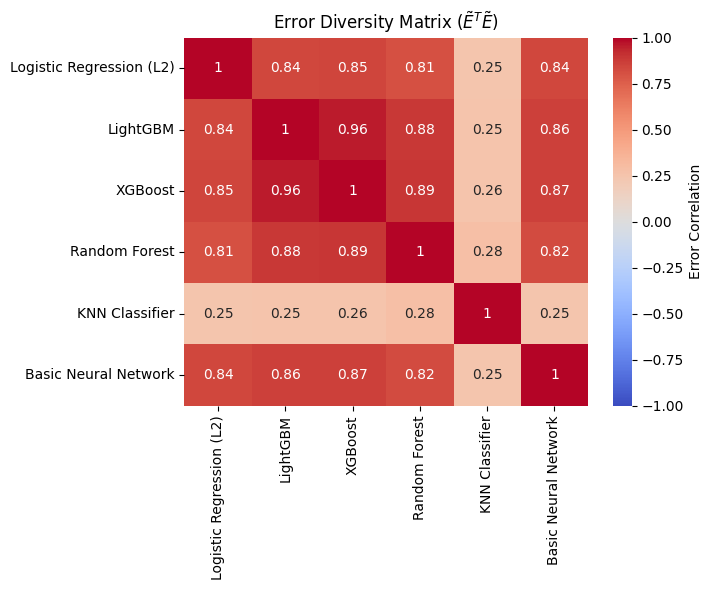

In [19]:
# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

In [20]:
# Where did we end up
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)
print_classifier_results(results)

Classifier Evaluation
Train games     : 227,972
Test games      : 5,426

Train accuracy  : 69.30%
Test accuracy   : 70.92%

Train log loss  : 0.5851
Test log loss   : 0.5553

Train ROC-AUC   : 0.7626
Test ROC-AUC    : 0.7879

Train confusion matrix:
[[78911 35075]
 [34911 79075]]

Test confusion matrix:
[[2022  797]
 [ 781 1826]]


## Save Logistic Regression

In [21]:
from pathlib import Path
from sklearn.base import clone
import joblib

artifact_dir = Path("../../artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Fit final frozen LR on 2003–2025 only
final_lr = clone(logistic_regression)
final_lr.fit(X_train, y_train)

# Save model + scaler pipeline
model_path = artifact_dir / "logistic_regression.joblib"
joblib.dump(final_lr, model_path)

print("Saved:", model_path)

Saved: ..\..\artifacts\logistic_regression.joblib


## 2026 Test plot

In [22]:
from pathlib import Path
import sys
import joblib
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

X_2026 = pd.read_csv(DATA_DIR / "X_test.csv")
y_2026 = pd.read_csv(DATA_DIR / "y_test.csv").values.ravel()

model = joblib.load(
    ARTIFACTS_DIR / "logistic_regression.joblib"
)

In [23]:
from src.datasets.multi_season_dataset import build_multi_season_dataset

raw_X_2026, raw_y_check, _ = build_multi_season_dataset(
    seasons=[2026]
)

assert len(raw_X_2026) == len(X_2026)
assert (raw_y_check.to_numpy() == y_2026).all()

y_pred = model.predict(X_2026)

game_results = pd.DataFrame({
    "DayNum": raw_X_2026["DayNum"].to_numpy(),
    "correct": y_pred == y_2026,
})

Starting season 2026...
Finished season 2026: 5426 rows built, 221 skipped, 5647 raw games

All seasons complete.
Seasons processed: 1
Total rows built: 5426
Total games skipped: 221
Total raw games: 5647
All row-count checks passed.


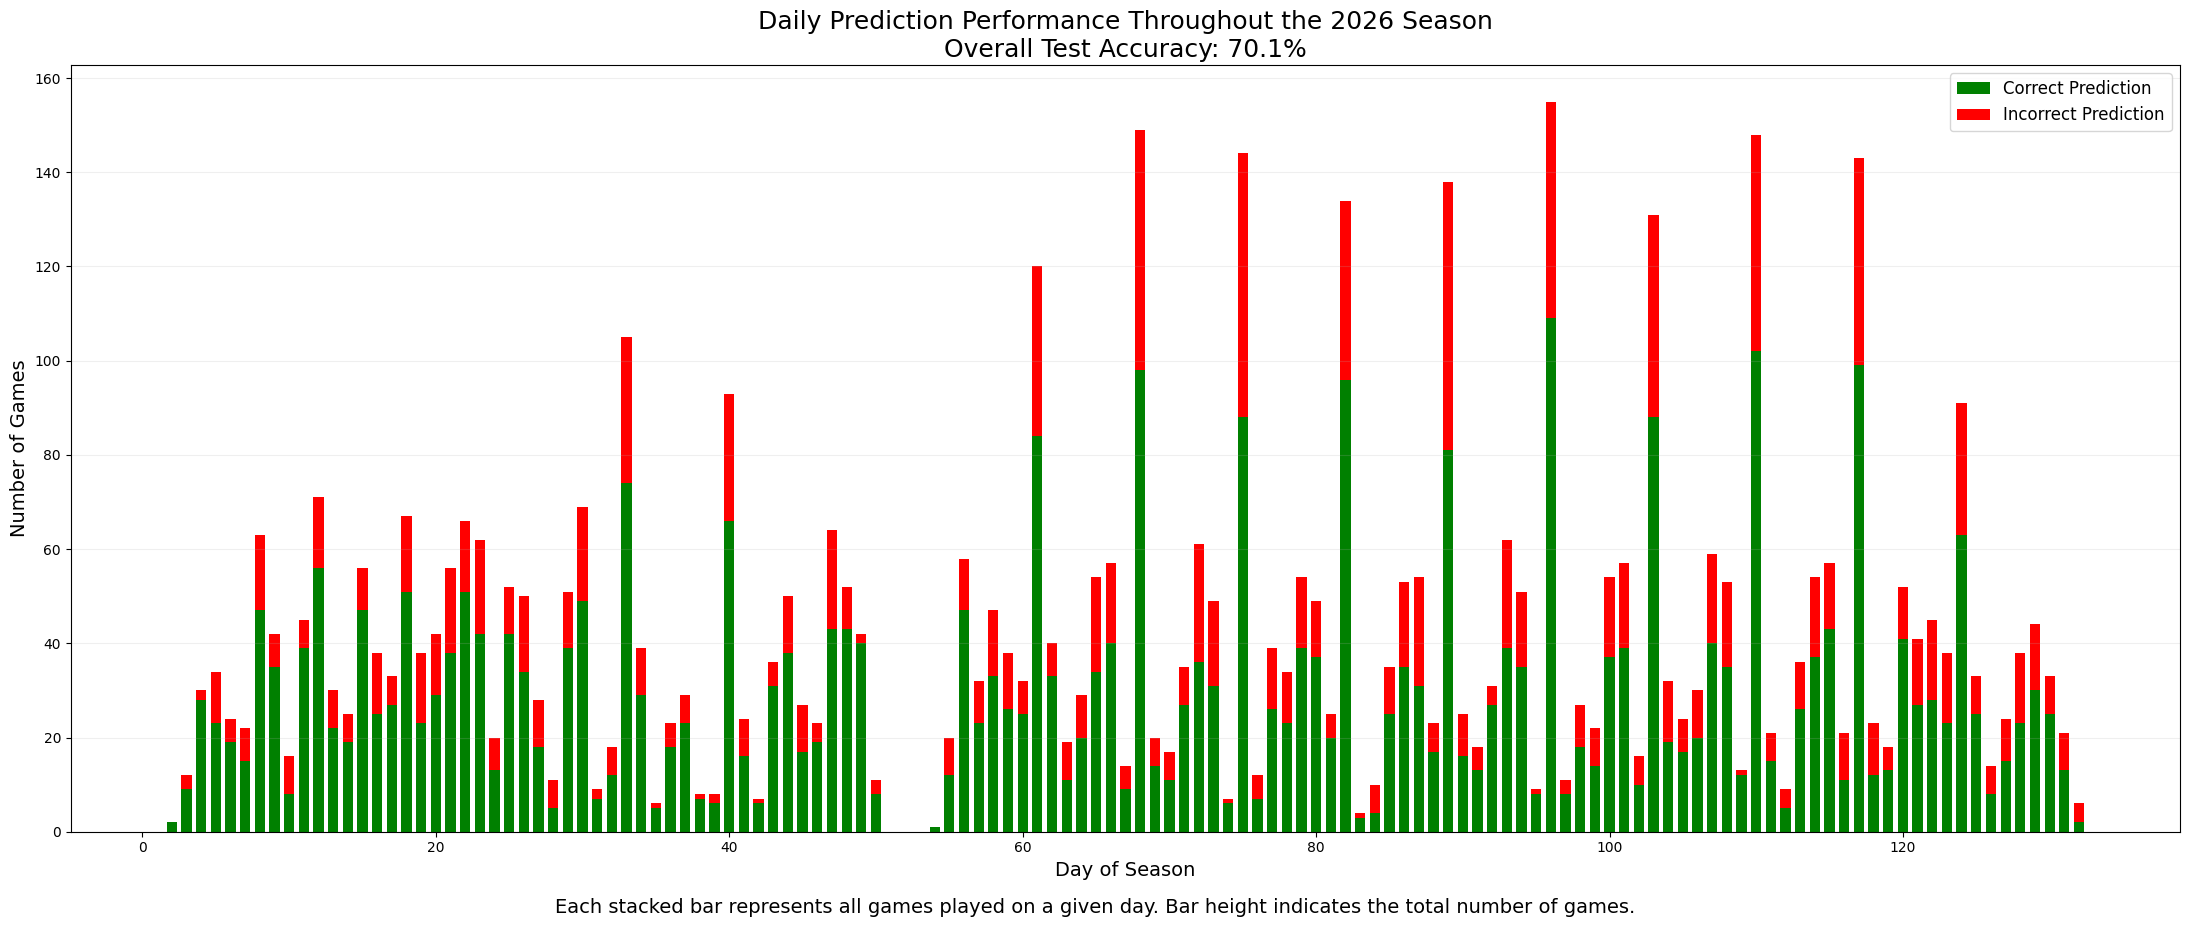

In [24]:
import matplotlib.pyplot as plt

daily = (
    game_results
    .groupby("DayNum")["correct"]
    .agg(["sum", "count"])
    .reset_index()
)

daily["correct"] = daily["sum"]
daily["incorrect"] = daily["count"] - daily["correct"]

overall_accuracy = game_results["correct"].mean() * 100

plt.figure(figsize=(22, 9))

plt.bar(
    daily["DayNum"],
    daily["correct"],
    color="green",
    width=0.7,
    label="Correct Prediction"
)

plt.bar(
    daily["DayNum"],
    daily["incorrect"],
    bottom=daily["correct"],
    color="red",
    width=0.7,
    label="Incorrect Prediction"
)

plt.xlabel("Day of Season", fontsize=14)
plt.ylabel("Number of Games", fontsize=14)

plt.title(
    "Daily Prediction Performance Throughout the 2026 Season\n"
    f"Overall Test Accuracy: {overall_accuracy:.1f}%",
    fontsize=18
)

plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.2)

plt.figtext(
    0.5,
    -0.02,
    "Each stacked bar represents all games played on a given day. "
    "Bar height indicates the total number of games.",
    ha="center",
    fontsize=14
)

plt.tight_layout()
plt.show()